In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

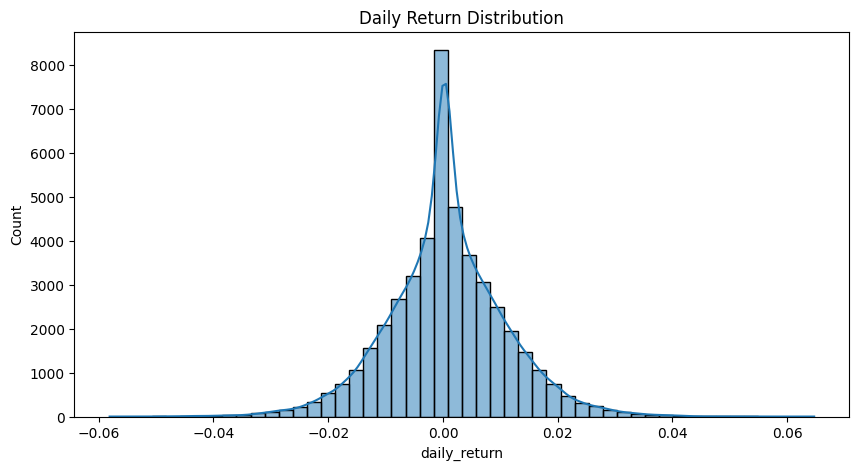

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

# Insight 1

Daily fund returns are centered around zero with occasional extreme positive and negative movements, which is typical for equity-oriented mutual funds.


In [5]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [1]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [3]:
cagr_df = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr_pct
25,120505,32.801599
21,119598,32.398084
39,149324,32.262108
36,148569,31.924486
34,148567,30.949920
30,120843,30.883326
2,100033,30.099704
38,149323,29.558105
16,119094,28.192608
19,119551,25.784921


In [4]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

print("CAGR file saved")

CAGR file saved


In [7]:
cagr_df = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr_pct
25,120505,32.801599
21,119598,32.398084
39,149324,32.262108
36,148569,31.924486
34,148567,30.949920
30,120843,30.883326
2,100033,30.099704
38,149323,29.558105
16,119094,28.192608
19,119551,25.784921


In [8]:
top10 = cagr_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.show()

NameError: name 'plt' is not defined

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

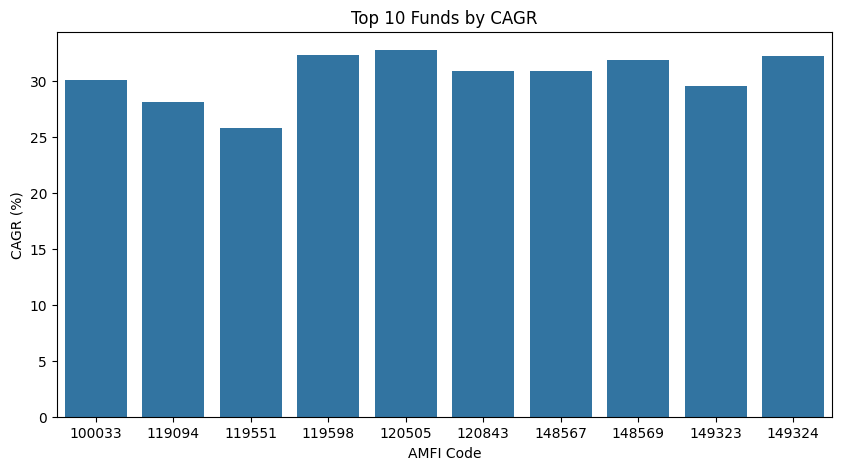

In [10]:
top10 = cagr_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.show()

# Insight 2

Funds with higher CAGR values demonstrated stronger long-term growth and wealth creation potential over the analysis period.

In [11]:
returns = pd.read_csv(
    "../data/processed/nav_with_returns.csv"
)

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
risk_free_rate = 0.065

sharpe_results = []

for fund in returns["amfi_code"].unique():

    fund_data = returns[
        returns["amfi_code"] == fund
    ]

    mean_return = fund_data[
        "daily_return"
    ].mean()

    std_return = fund_data[
        "daily_return"
    ].std()

    sharpe = (
        (mean_return - risk_free_rate/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [13]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


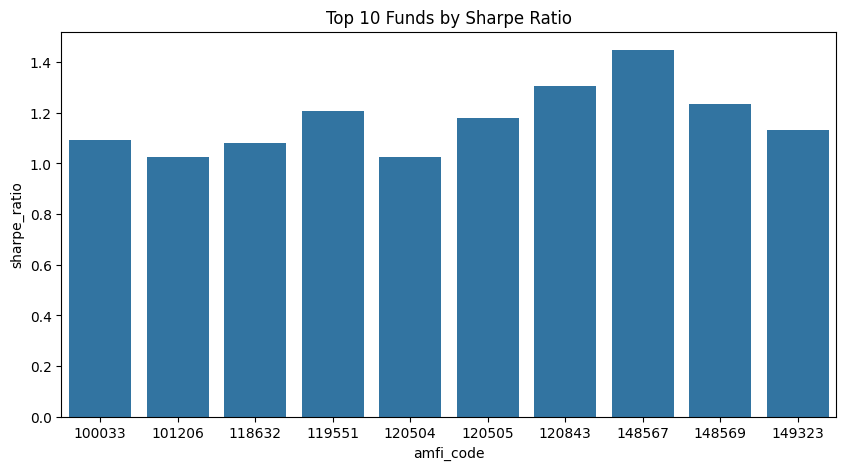

In [14]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

# Insight 3

Funds with higher Sharpe Ratios delivered superior returns relative to the level of risk undertaken, indicating stronger risk-adjusted performance.

In [15]:
sharpe_df.to_csv(
    "../data/processed/sharpe_results.csv",
    index=False
)

print("Sharpe results saved")

Sharpe results saved


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
returns = pd.read_csv(
    "../data/processed/nav_with_returns.csv"
)

In [18]:
sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [19]:
sortino_results = []

for fund in returns["amfi_code"].unique():

    fund_data = returns[
        returns["amfi_code"] == fund
    ]

    mean_return = fund_data[
        "daily_return"
    ].mean()

    downside_returns = fund_data[
        fund_data["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside_returns.std()

    if downside_std != 0:

        sortino = (
            (mean_return - risk_free_rate/252)
            / downside_std
        ) * np.sqrt(252)

        sortino_results.append(
            [fund, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [20]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


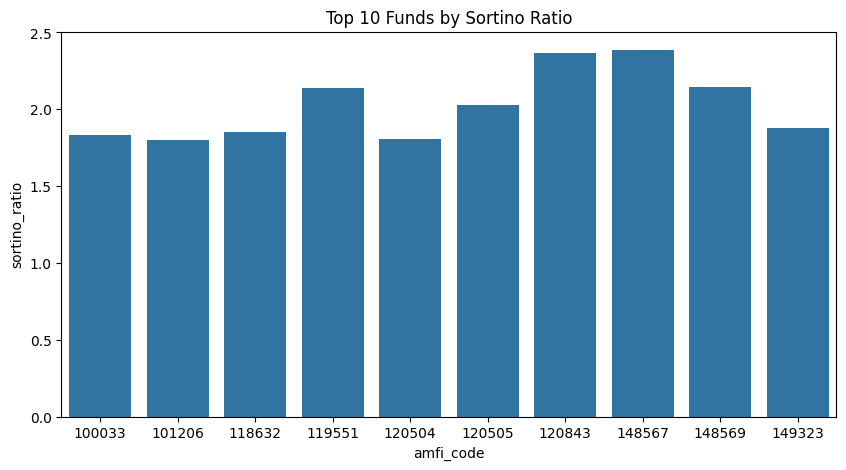

In [21]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_sortino,
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

# Insight 4

Funds with higher Sortino Ratios demonstrated better downside-risk management, generating strong returns while minimizing negative-return volatility.

In [22]:
benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv"
)

print(benchmark.columns)

benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [23]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [24]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [25]:
from scipy.stats import linregress

In [27]:
returns["date"] = pd.to_datetime(
    returns["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

C:\Users\nalla\AppData\Local\Temp\ipykernel_18288\1143916971.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nifty100["date"] = pd.to_datetime(


In [28]:
print(returns["date"].dtype)
print(nifty100["date"].dtype)

datetime64[ns]
datetime64[ns]


In [29]:
alpha_beta_results = []

for fund in returns["amfi_code"].unique():

    fund_data = returns[
        returns["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r, p, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_annual = alpha * 252

        alpha_beta_results.append(
            [fund, alpha_annual, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [30]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


# Insight 5

Funds with positive Alpha generated returns above benchmark expectations, while Beta values measured their sensitivity to market movements. Higher Alpha indicates superior fund management performance.

In [31]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    fund_data = fund_data.copy()

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [32]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


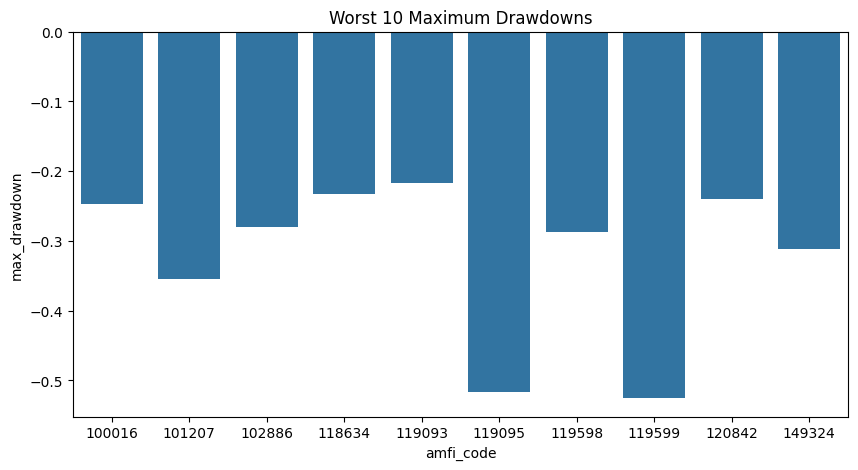

In [33]:
worst10 = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=worst10,
    x="amfi_code",
    y="max_drawdown"
)

plt.title("Worst 10 Maximum Drawdowns")

plt.show()

# Insight 6

Funds with larger maximum drawdowns experienced deeper losses during market corrections, indicating higher downside risk exposure.

In [34]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [35]:
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [36]:
scheme_perf = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

print(scheme_perf.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [37]:
scorecard = scheme_perf[
    ["amfi_code", "scheme_name",
     "return_3yr_pct",
     "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code",
    how="left"
)


In [38]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

# Lower expense ratio is better
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

In [39]:
scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code",
    how="left"
)

# Less negative drawdown is better
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [40]:
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

In [41]:
scorecard["fund_score"] = 100 - (
    (scorecard["fund_score"] - scorecard["fund_score"].min())
    /
    (scorecard["fund_score"].max() - scorecard["fund_score"].min())
) * 100

In [42]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    ["amfi_code", "scheme_name", "fund_score"]
].head(10)

,amfi_code,scheme_name,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,67.401392


In [43]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


# Insight 7

The composite fund scorecard combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection to identify the most balanced mutual fund schemes.

In [44]:
scorecard[
    ["amfi_code", "scheme_name", "fund_score"]
].head(10)

,amfi_code,scheme_name,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,67.401392


# Insight 8

ICICI Pru Midcap Fund achieved the highest composite score by combining strong 3-year returns, favorable risk-adjusted performance, positive alpha generation, and efficient cost structure.

In [45]:
top5_funds = scorecard.head(5)["amfi_code"].tolist()

print(top5_funds)

[120505, 120843, 100033, 119598, 148567]


In [46]:
top5_nav = nav[
    nav["amfi_code"].isin(
        [120505, 120843, 100033, 119598, 148567]
    )
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [47]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [48]:
benchmark_norm = benchmark.copy()

benchmark_norm["normalized_index"] = (
    benchmark_norm.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

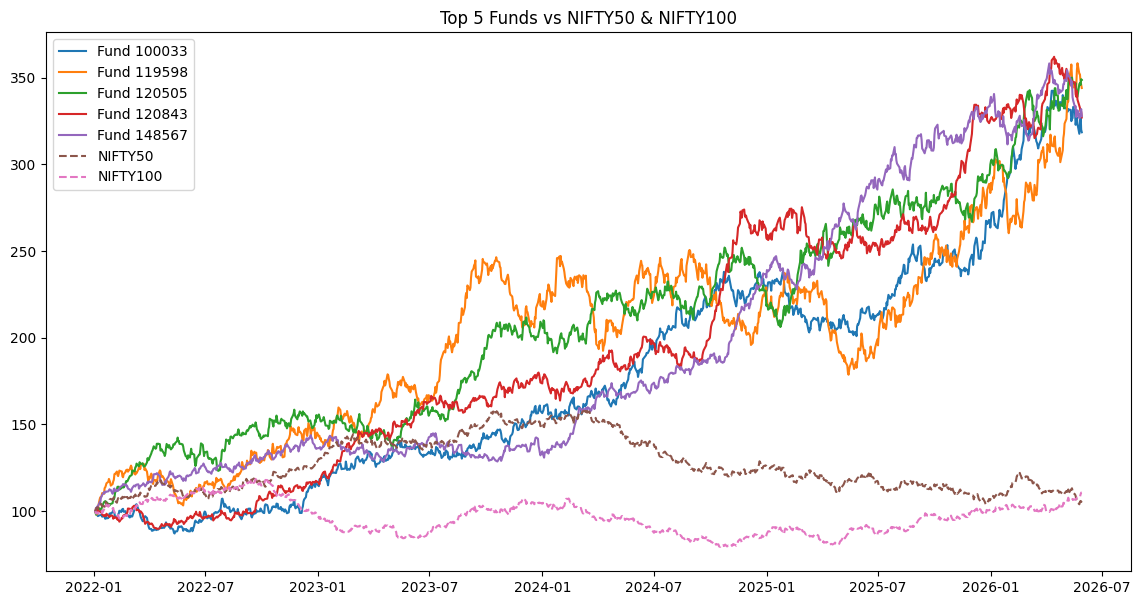

In [49]:
plt.figure(figsize=(14,7))

for fund in top5_nav["amfi_code"].unique():

    data = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        data["date"],
        data["normalized_nav"],
        label=f"Fund {fund}"
    )

for idx in ["NIFTY50", "NIFTY100"]:

    data = benchmark_norm[
        benchmark_norm["index_name"] == idx
    ]

    plt.plot(
        data["date"],
        data["normalized_index"],
        linestyle="--",
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.legend()

plt.show()

In [50]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [51]:
tracking_results = []

for fund in top5_funds:

    fund_data = returns[
        returns["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"]
         - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append(
        [fund, tracking_error]
    )

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


# Insight 9

The top-ranked funds consistently outperformed benchmark indices over the analysis period. Tracking Error analysis showed the degree to which each fund deviated from benchmark performance.

In [52]:
tracking_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)